## Neural Network Model

Next we train a Multi-Layer Perceptron (MLP) regressor to predict rate_avg. Neural networks learn by passing data forward through layers of weighted connections, computing a prediction, and adjusting those weights backwards based on the error. For this model we compare a 2-layer and 3-layer MLP architecture to assess whether adding depth improves predictive performance on our Airbnb dataset.

In [25]:
# load required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

### Load and Prepare Data

Neural networks are sensitive to the scale of input features. Unlike tree-based models, which split on thresholds and are scale-invariant, MLPs use gradient-based optimization where large differences in feature magnitudes can cause unstable or slow training. We standardize all features to have mean 0 and standard deviation 1 using StandardScaler before training. 

In [26]:
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA2.csv")
print(f"Dataset shape: {df.shape}")

# drop feature we are predicting
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")

Dataset shape: (3225, 71)
Train size: (2580, 70), Test size: (645, 70)


### 2 Layer MLP - 50 Neurons
We start with the simplest MLP - a 2-layer network with a single hidden layer of 50 neurons. This serves as our baseline neural network, with minimal capacity but fast training and allows us to compare with more complex models later on. 

In [27]:
id="fix3"
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


mlp_2layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_2layer_50.fit(X_train_scaled, y_train)
y_pred_2layer_50 = mlp_2layer_50.predict(X_test_scaled)

mse_2_50  = mean_squared_error(y_test, y_pred_2layer_50)
rmse_2_50 = np.sqrt(mse_2_50)
mae_2_50  = mean_absolute_error(y_test, y_pred_2layer_50)
mape_2_50 = mean_absolute_percentage_error(y_test, y_pred_2layer_50)
r2_2_50   = r2_score(y_test, y_pred_2layer_50)

print("2-Layer 50 neuron MLP Results")
print("MSE: ", mse_2_50)
print("RMSE:", rmse_2_50)
print("MAE: ", mae_2_50)
print("MAPE:", mape_2_50)
print("R²:  ", r2_2_50)



2-Layer 50 neuron MLP Results
MSE:  1082.675327074307
RMSE: 32.9040320792803
MAE:  21.67468614554057
MAPE: 0.19836617960649594
R²:   0.8982549548663571


The 2 layer 50 neuron model produced the weakest results of all 9 configurations with an RMSE of 32.90, MAE of 21.67, and R² of 0.898, meaning it explains about 90% of the variance in rate_avg. The high MAE of 21.67 suggests predictions are off by nearly $22 on average, indicating that a single small hidden layer lacks the capacity to capture the complexity of Airbnb pricing.

### 3 Layer MLP - 50 Neurons
We add a second hidden layer while keeping 50 neurons per layer. The additional layer allows the model to learn more complex representations of the data, potentially capturing relationships that a single hidden layer could have missed. Keeping the neuron count low means the added capacity comes from depth rather than width.

In [28]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_3layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,50),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)


mlp_3layer_50.fit(X_train_scaled, y_train)
y_pred_3layer_50 = mlp_3layer_50.predict(X_test_scaled)

mse_3_50  = mean_squared_error(y_test, y_pred_3layer_50)
rmse_3_50 = np.sqrt(mse_3_50)
mae_3_50 = mean_absolute_error(y_test, y_pred_3layer_50)
mape_3_50 = mean_absolute_percentage_error(y_test, y_pred_3layer_50)
r2_3_50   = r2_score(y_test, y_pred_3layer_50)

print("3-Layer 50 neuron MLP Results")
print("MSE: ", mse_3_50)
print("RMSE:", rmse_3_50)
print("MAE: ", mae_3_50)
print("MAPE:", mape_3_50)
print("R²:  ", r2_3_50)

3-Layer 50 neuron MLP Results
MSE:  687.9976099872413
RMSE: 26.229708537977338
MAE:  16.580160692481726
MAPE: 0.14602473810173075
R²:   0.9353450234530134


RMSE drops from 32.90 to 26.23 and R² improves to 0.935, which shows that there is significant improvement over the 2-layer version. This suggests that depth even without increasing neuron count helps the model to learn higher-level patterns in the data. MAE also falls to 16.58.

### 4-Layer MLP - 50 Neurons
We extend to three hidden layers, still with 50 neurons each. With a relatively small neuron count, the risk of overfitting is lower, but the model may struggle to capture the full complexity of the data compared to wider structure of the network. 

In [29]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
mlp_4layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,50,50),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_4layer_50.fit(X_train_scaled, y_train)
y_pred_4layer_50 = mlp_4layer_50.predict(X_test_scaled)

mse_4_50  = mean_squared_error(y_test, y_pred_4layer_50)
rmse_4_50 = np.sqrt(mse_4_50)
mae_4_50  = mean_absolute_error(y_test, y_pred_4layer_50)
mape_4_50 = mean_absolute_percentage_error(y_test, y_pred_4layer_50)
r2_4_50   = r2_score(y_test, y_pred_4layer_50)

print("4-Layer 50 neuron MLP Results")
print("MSE: ", mse_4_50)
print("RMSE:", rmse_4_50)
print("MAE: ", mae_4_50)
print("MAPE:", mape_4_50)
print("R²:  ", r2_4_50)

4-Layer 50 neuron MLP Results
MSE:  554.2862956581843
RMSE: 23.54328557483395
MAE:  15.449681617735576
MAPE: 0.1333600645189384
R²:   0.9479106221796896


RMSE drops further to 23.54 and R² reaches 0.948, with MAE at 15.45. This is the best performer in the 50-neuron group, suggesting that for smaller networks, adding depth consistently helps. 

### 2-Layer MLP - 100 Neurons
We now double the neuron count to 100 per hidden layer, starting again with a single hidden layer and then increase hidden layers in later models. 

In [30]:
mlp_2layer_100 = MLPRegressor(
    hidden_layer_sizes=(100,),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_2layer_100.fit(X_train_scaled, y_train)
y_pred_2layer_100 = mlp_2layer_100.predict(X_test_scaled)

mse_2_100 = mean_squared_error(y_test, y_pred_2layer_100)
rmse_2_100 = np.sqrt(mse_2_100)
mae_2_100  = mean_absolute_error(y_test, y_pred_2layer_100)
mape_2_100 = mean_absolute_percentage_error(y_test, y_pred_2layer_100)
r2_2_100   = r2_score(y_test, y_pred_2layer_100)

print("2-Layer 100 Neuron MLP Results") 
print("MSE: ", mse_2_100)
print("RMSE:", rmse_2_100)
print("MAE: ", mae_2_100)
print("MAPE:", mape_2_100)
print("R²:  ", r2_2_100)

2-Layer 100 Neuron MLP Results
MSE:  835.0470947617705
RMSE: 28.897181432827846
MAE:  18.731062894523493
MAPE: 0.17105956206269368
R²:   0.9215259623816822


Doubling the neuron count to 100 while keeping a single hidden layer gives RMSE of 28.90 and R² of 0.922. This is better than the 2-layer 50-neuron model but worse than the 3-layer 50-neuron version.

### 3-Layer MLP - 100 Neurons


In [31]:
mlp_3layer_100 = MLPRegressor(
    hidden_layer_sizes=(100, 100),  # 2 hidden layers
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_3layer_100.fit(X_train_scaled, y_train)
y_pred_3layer_100 = mlp_3layer_100.predict(X_test_scaled)

mse_3_100  = mean_squared_error(y_test, y_pred_3layer_100)
rmse_3_100 = np.sqrt(mse_3_100)
mae_3_100  = mean_absolute_error(y_test, y_pred_3layer_100)
mape_3_100 = mean_absolute_percentage_error(y_test, y_pred_3layer_100)
r2_3_100   = r2_score(y_test, y_pred_3layer_100)

print("3-Layer 100 Neuron MLP Results")
print("MSE: ", mse_3_100)
print("RMSE:", rmse_3_100)
print("MAE: ", mae_3_100)
print("MAPE:", mape_3_100)
print("R²:  ", r2_3_100)

3-Layer 100 Neuron MLP Results
MSE:  572.1310519885066
RMSE: 23.919261108748877
MAE:  16.100210771277737
MAPE: 0.14613288387902423
R²:   0.946233650798866


Two hidden layers of 100 neurons each achieves an RMSE of 23.92 and R² of 0.946. This is comparable to the 4-layer 50-neuron model, showing that the combination of moderate depth and moderate width performs similarly to a deeper, narrower network. 

### 4-Layer MLP - 100 Neurons

We extend the network by adding a third hidden layer to assess whether additional depth helps capture more complex patterns in the data.

In [32]:
mlp_4layer_100 = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_4layer_100.fit(X_train_scaled, y_train)
y_pred_4layer_100 = mlp_4layer_100.predict(X_test_scaled)

mse_4_100  = mean_squared_error(y_test, y_pred_4layer_100)
rmse_4_100 = np.sqrt(mse_4_100)
mae_4_100  = mean_absolute_error(y_test, y_pred_4layer_100)
mape_4_100 = mean_absolute_percentage_error(y_test, y_pred_4layer_100)
r2_4_100   = r2_score(y_test, y_pred_4layer_100)

print("4-Layer 100 Neuron MLP Results")
print("MSE: ", mse_4_100)
print("RMSE:", rmse_4_100)
print("MAE: ", mae_4_100)
print("MAPE:", mape_4_100)
print("R²:  ", r2_4_100)

4-Layer 100 Neuron MLP Results
MSE:  597.9984187891057
RMSE: 24.454006190992626
MAE:  16.4798130424794
MAPE: 0.14843389345056346
R²:   0.9438027499213817


Adding a third hidden layer at 100 neurons actually slightly worsens performance compared to the 3-layer version as we can see, RMSE increases from 23.92 to 24.45 and R² drops from 0.946 to 0.944. This is the first case where adding an extra layer actually makes performance slightly worse, which makes sense given our dataset is relatively small and the model is starting to become more complex than the data can support.

### 2-Layer MLP - 200 Nodes
We now test with 200 neurons per hidden layer starting with a single hidden layer. Wider layers allow the model to learn a more about set of feature representations in a single step. This can be helpful when there are many input features, as is the case with our 70-feature dataset.

In [33]:
mlp_2layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_2layer_200.fit(X_train_scaled, y_train)
y_pred_2layer_200 = mlp_2layer_200.predict(X_test_scaled)

mse_2_200  = mean_squared_error(y_test, y_pred_2layer_200)
rmse_2_200 = np.sqrt(mse_2_200)
mae_2_200  = mean_absolute_error(y_test, y_pred_2layer_200)
mape_2_200 = mean_absolute_percentage_error(y_test, y_pred_2layer_200)
r2_2_200   = r2_score(y_test, y_pred_2layer_200)

print("2-Layer 200 Neuron MLP Results")
print("MSE: ", mse_2_200)
print("RMSE:", rmse_2_200)
print("MAE: ", mae_2_200)
print("MAPE:", mape_2_200)
print("R²:  ", r2_2_200)

2-Layer 200 Neuron MLP Results
MSE:  650.1709438654145
RMSE: 25.49844983259599
MAE:  16.268179229876335
MAPE: 0.1467015990686806
R²:   0.9388998064572782


As shown above the RMSE for the model is 25.498 and R² of 0.939. This result is worse than the best 3 and 4-layer models, reinforcing the pattern that depth matters more than width alone for this dataset.

### 3-Layer MLP - 200 Neurons
We combine two hidden layers with 200 neurons each. This is one of the largest networks we test, with significantly more parameters than earlier configurations. On a dataset of only 3,225 rows, models of this size risk fitting noise in the training data. 

In [34]:
mlp_3layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,200),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_3layer_200.fit(X_train_scaled, y_train)
y_pred_3layer_200 = mlp_3layer_200.predict(X_test_scaled)

mse_3_200  = mean_squared_error(y_test, y_pred_3layer_200)
rmse_3_200 = np.sqrt(mse_3_200)
mae_3_200 = mean_absolute_error(y_test, y_pred_3layer_200)
mape_3_200 = mean_absolute_percentage_error(y_test, y_pred_3layer_200)
r2_3_200   = r2_score(y_test, y_pred_3layer_200)

print("3-Layer 200 Neurons MLP Results")
print("MSE: ", mse_3_200)
print("RMSE:", rmse_3_200)
print("MAE: ", mae_3_200)
print("MAPE:", mape_3_200)
print("R²:  ", r2_3_200)

3-Layer 200 Neurons MLP Results
MSE:  523.6388793928933
RMSE: 22.88315711157211
MAE:  14.830227319133098
MAPE: 0.1362817816504345
R²:   0.9507907309927055


The 3-layer 200-neuron model is the best overall performer across all 9 configurations, achieving the lowest RMSE of 22.88, lowest MAE of 14.83, and highest R² of 0.951. 


### 4-Layer MLP - 200 Neurons
The final and largest model configuration uses three hidden layers of 200 neurons each, giving the model the most capacity of any previous model that has been tested. While this level of depth and width can be powerful on large datasets, it may be excessive for our dataset size and could show signs of overfitting.

In [35]:
mlp_4layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,200,200),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_4layer_200.fit(X_train_scaled, y_train)
y_pred_4layer_200 = mlp_4layer_200.predict(X_test_scaled)

mse_4_200  = mean_squared_error(y_test, y_pred_4layer_200)
rmse_4_200 = np.sqrt(mse_4_200)
mae_4_200  = mean_absolute_error(y_test, y_pred_4layer_200)
mape_4_200 = mean_absolute_percentage_error(y_test, y_pred_4layer_200)
r2_4_200   = r2_score(y_test, y_pred_4layer_200)

print("4-Layer 200 Neurons MLP Results")
print("MSE: ", mse_4_200)
print("RMSE:", rmse_4_200)
print("MAE: ", mae_4_200)
print("MAPE:", mape_4_200)
print("R²:  ", r2_4_200)

4-Layer 200 Neurons MLP Results
MSE:  664.8366183519795
RMSE: 25.78442588757755
MAE:  15.38000251647351
MAPE: 0.1252066585008495
R²:   0.9375215911463382


Adding a fourth layer actually hurts performance, with RMSE rising back to 25.78 and R² dropping to 0.938. This is a clear sign that the model has become too complex for our dataset size, with only 3,225 rows, having too many parameters causes the model to become unstable rather than improve it.

### Loss Curves

The loss curves track how training error decreases over each epoch for both models.

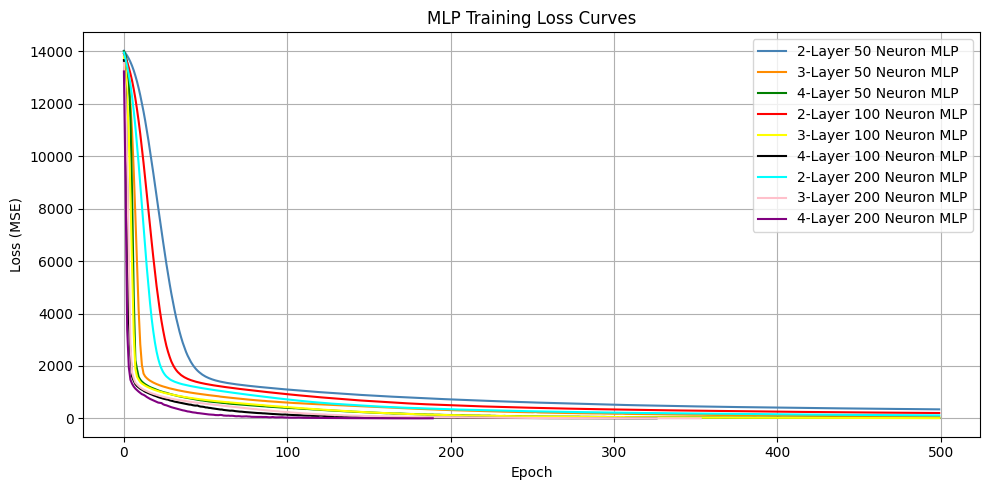

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_2layer_50.loss_curve_, label='2-Layer 50 Neuron MLP', color='steelblue')
plt.plot(mlp_3layer_50.loss_curve_, label='3-Layer 50 Neuron MLP', color='darkorange')
plt.plot(mlp_4layer_50.loss_curve_, label='4-Layer 50 Neuron MLP', color='green')
plt.plot(mlp_2layer_100.loss_curve_, label='2-Layer 100 Neuron MLP', color='red')
plt.plot(mlp_3layer_100.loss_curve_, label='3-Layer 100 Neuron MLP', color='yellow')
plt.plot(mlp_4layer_100.loss_curve_, label='4-Layer 100 Neuron MLP', color='black')
plt.plot(mlp_2layer_200.loss_curve_, label='2-Layer 200 Neuron MLP', color='cyan')
plt.plot(mlp_3layer_200.loss_curve_, label='3-Layer 200 Neuron MLP', color='pink')
plt.plot(mlp_4layer_200.loss_curve_, label='4-Layer 200 Neuron MLP', color='purple')
plt.title("MLP Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Actual vs Predicted - Side by Side

These scatter plots compare each model's predicted values against the actual rate_avg values on the test set. Points close to the dashed diagonal line indicate accurate predictions. Comparing both plots side by side shows whether the additional layer produces meaningfully different predictions.

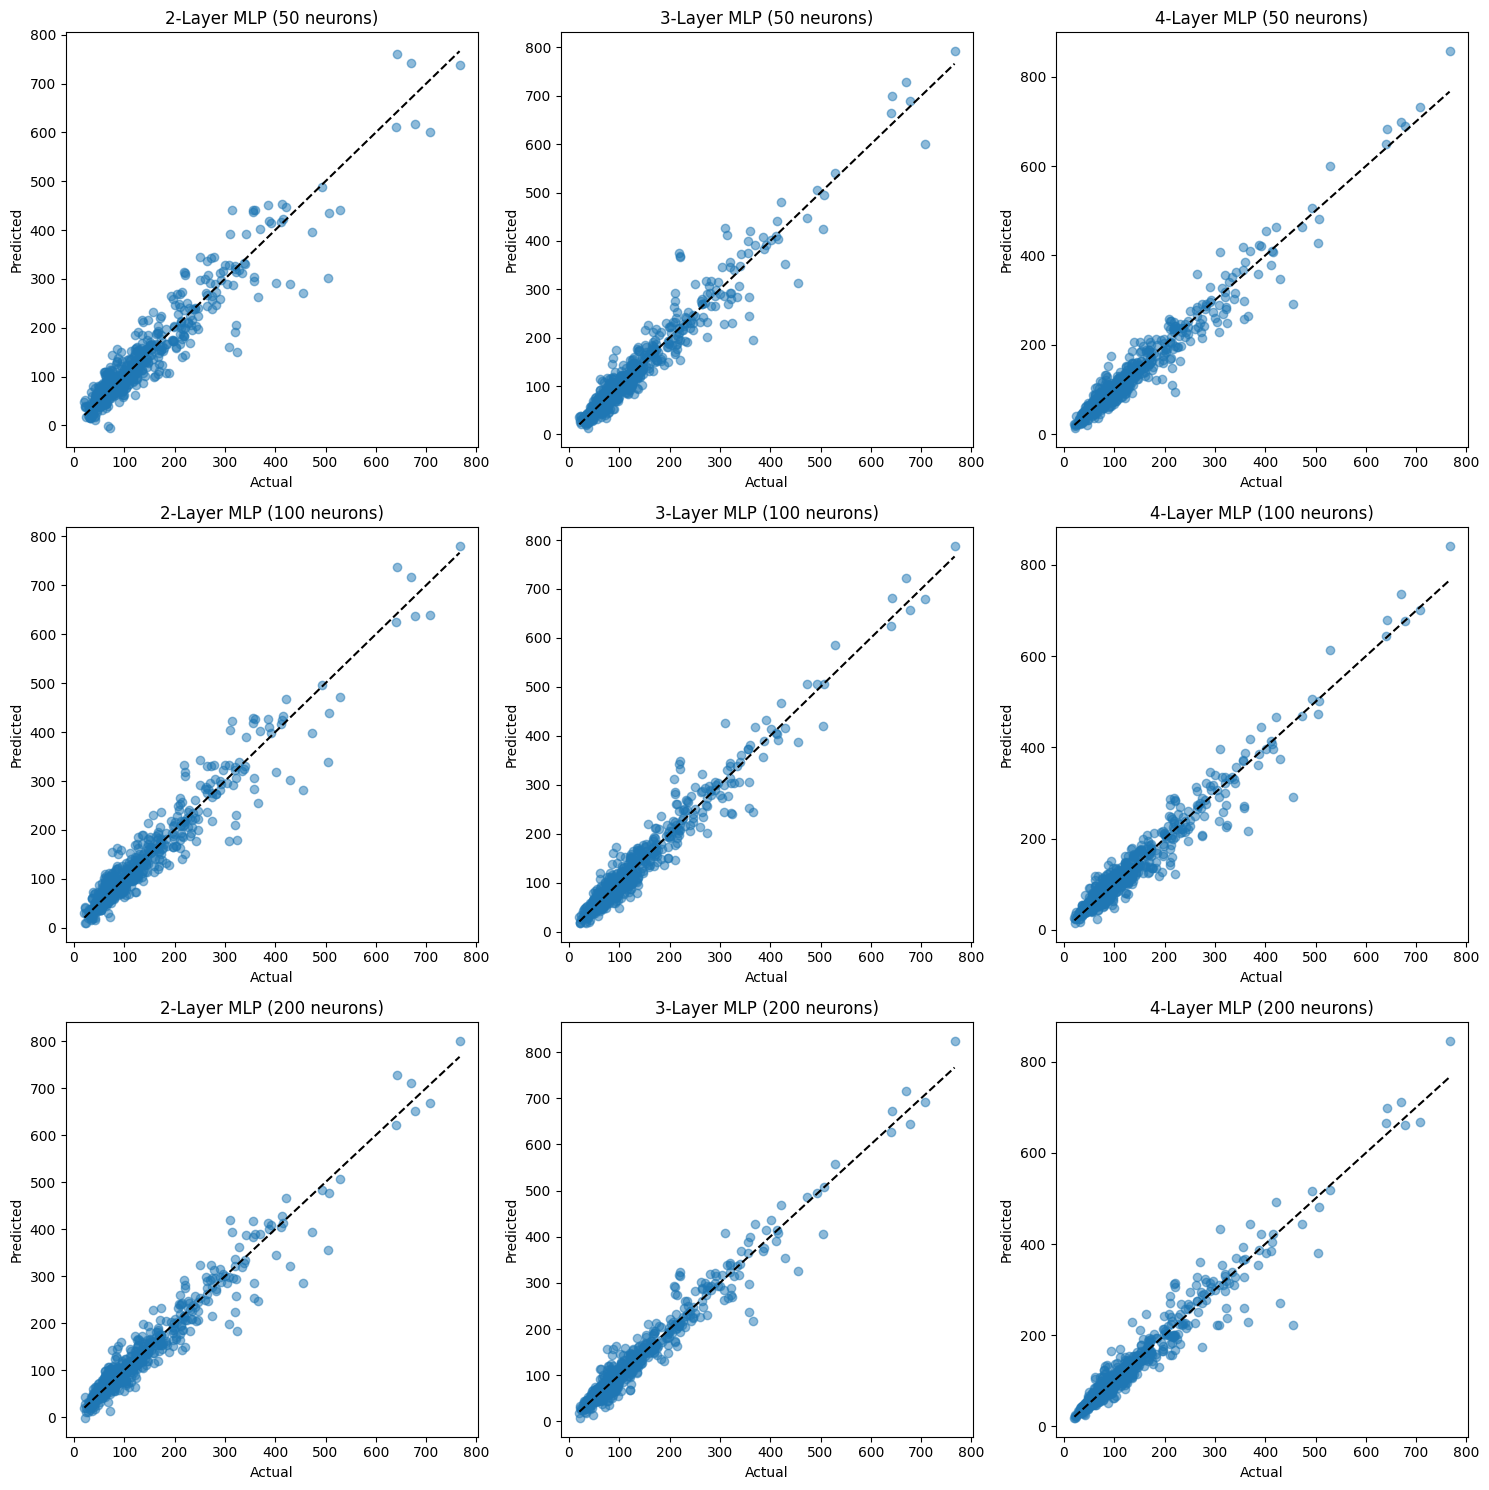

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Organize predictions
predictions = {
    50: [y_pred_2layer_50, y_pred_3layer_50, y_pred_4layer_50],
    100: [y_pred_2layer_100, y_pred_3layer_100, y_pred_4layer_100],
    200: [y_pred_2layer_200, y_pred_3layer_200, y_pred_4layer_200]
}

layer_labels = ["2-Layer", "3-Layer", "4-Layer"]

for i, (neurons, preds) in enumerate(predictions.items()):
    for j, y_pred in enumerate(preds):
        ax = axes[i, j]

        ax.scatter(y_test, y_pred, alpha=0.5)
        
        # perfect prediction line
        ax.plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'k--')

        ax.set_title(f"{layer_labels[j]} MLP ({neurons} neurons)")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

### Results Summary

The table below compares all MLP's across all standardized error metrics.

In [38]:

results = {
    (50, 2): (mse_2_50, rmse_2_50, mae_2_50, mape_2_50, r2_2_50),
    (50, 3): (mse_3_50, rmse_3_50, mae_3_50, mape_3_50, r2_3_50),
    (50, 4): (mse_4_50, rmse_4_50, mae_4_50, mape_4_50, r2_4_50),

    (100, 2): (mse_2_100, rmse_2_100, mae_2_100, mape_2_100, r2_2_100),
    (100, 3): (mse_3_100, rmse_3_100, mae_3_100, mape_3_100, r2_3_100),
    (100, 4): (mse_4_100, rmse_4_100, mae_4_100, mape_4_100, r2_4_100),

    (200, 2): (mse_2_200, rmse_2_200, mae_2_200, mape_2_200, r2_2_200),
    (200, 3): (mse_3_200, rmse_3_200, mae_3_200, mape_3_200, r2_3_200),
    (200, 4): (mse_4_200, rmse_4_200, mae_4_200, mape_4_200, r2_4_200),
}

rows = []

for (neurons, layers), (mse, rmse, mae, mape, r2) in results.items():
    rows.append({
        "Model": f"{layers}-Layer ({neurons} neurons)",
        "Neurons": neurons,
        "Layers": layers,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "MAPE": round(mape, 4),
        "R²": round(r2, 6),
    })

mlp_summary = pd.DataFrame(rows) \
    .sort_values("RMSE") \
    .reset_index(drop=True)

mlp_summary

,Model,Neurons,Layers,MSE,RMSE,MAE,MAPE,R²
0,3-Layer (200 neurons),200,3,523.6389,22.8832,14.8302,0.1363,0.950791
1,4-Layer (50 neurons),50,4,554.2863,23.5433,15.4497,0.1334,0.947911
2,3-Layer (100 neurons),100,3,572.1311,23.9193,16.1002,0.1461,0.946234
3,4-Layer (100 neurons),100,4,597.9984,24.4540,16.4798,0.1484,0.943803
4,2-Layer (200 neurons),200,2,650.1709,25.4984,16.2682,0.1467,0.938900
5,4-Layer (200 neurons),200,4,664.8366,25.7844,15.3800,0.1252,0.937522
6,3-Layer (50 neurons),50,3,687.9976,26.2297,16.5802,0.1460,0.935345
7,2-Layer (100 neurons),100,2,835.0471,28.8972,18.7311,0.1711,0.921526
8,2-Layer (50 neurons),50,2,1082.6753,32.9040,21.6747,0.1984,0.898255


### Drawbacks of Neural Networks

While MLPs are flexible and capable of capturing complex nonlinear relationships, there are some limitations worth acknowledging in the context of this analysis. Neural networks are often considered black box models, meaning it is difficult to interpret how individual features contribute to predictions, unlike tree-based methods where feature importance scores provide direct insight. Performance is also heavily dependent on input quality, requiring careful feature scaling and preprocessing before training. Finally, MLPs have a large number of parameters and can overfit if not properly regularized, particularly on smaller datasets like ours where tree-based ensemble methods may generalize more reliably.

### Analyzing the Results

These are our neural network models where we ran 9 variations, 3 models with 50, 100, and 200 neuons each, with 1,2,and 3 hidden layers -> which correlated to a 2,3,4 layer model. We used the Rectified Linear Unit function as our activation function as it was the best suited for our model, and the other methods we learned were largely for classification models. 

From the results, it seems that just the number of neurons or layers alone don't translate to a better perfomance. For example above,the second best model is the NN of 4 Layer 50 neuron, outperforming many 100 and 200 neuron NN models. Additionally, a 4 Layer model wasn't always the best model, oftentimes 3 Layers performed better for each variation. 

In the end of the models tested, the best performing model is the 3 layer 200 neuron NN with a R squared score of 0.95 meaning it was able to explain 95% of the variance in the data while also predicting within about 15$ of the actual price. 

**Additionally, from the MLP training loss curve we can see that all the models drop sharply in the beginning at around the 100 epoch mark and then gradually flatten out. This means that majority of our models were optimized by the 100th rerun of the data. Additionally we can see that models with more layers and higher amounts of neurons dropped and flattened out faster than those with less layers and neurons. Although this loss curve was created using the training data which could be undermining the possibility of overfitting, we can see that the model is not very overfitted due to the high values achieved in in the error metrics evaluated using the test data.***

The training loss curves show that all models converge successfully, with larger and deeper networks learning faster and achieving lower final loss values. Models with higher neuron counts (especially 200 neurons) and moderate depth (3 layers) perform best, while adding additional layers provides minimal improvement. Additionally, most models stabilize after approximately 100–200 epochs, suggesting that further training yields no better results.